In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% ! important;}
div.cell.code_cell.rendered{width:100%}
div.input_prompt{padding:0px}
div.CodeMirror {font-family:Consolas ; font-size:12pt;}
div.text_cell_render.rendered_html {font-size:12pt;}
div.output {font-size:12pt; font-weight:bold}
div.input {font-family:Consolas ; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper {padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<b><font size="6" color="red">ch.05 LSTM(RNN, GUR)으로 영화평 구분하기</font></b>
- lmdb사이트의 5만개 영화 감상평 : Train/test - 타겟변수 : 부정/긍정

# 1. 패키지 import

In [6]:
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from time import time # unix time을 계산하기 위해

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense

from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score
import pandas as pd

# 2. 하이퍼 파라미터 설정
- 하이퍼파라미터를 바꾸면 모델의 정확도나 속도에 차이남

In [3]:
MY_WORDS = 10000 # imdb 데이터 안의 단어 수
MY_LENGTH = 80   # 독립변수 차원(영화평 단어수 80개로 맞출 예정)
MY_EMBED = 32    # Embedding 결과 차원
MY_HIDDEN = 62   # LSTM의 unit의 수

MY_EPOCH = 10    # fit 반복학습수
MY_BATCH = 200   # 배치사이즈(fit할 때, 매번 가져오는 데이터 수)

# 3. 데이터 불러오기

In [5]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=MY_WORDS)
print('학습용 독립변수 모양', X_train.shape)
print('학습용 타겟변수 모양', y_train.shape)
print('학습용 독립변수 샘플', X_train[0][:80])
print('학습용 타겟변수(0:부정/1:긍정)', y_train[0])
print('테스트용 독립변수 모양 :', X_test.shape)
print('테스트용 타겟변수 모양 :', y_test.shape)

학습용 독립변수 모양 (25000,)
학습용 타겟변수 모양 (25000,)
학습용 독립변수 샘플 [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17]
학습용 타겟변수(0:부정/1:긍정) 1
테스트용 독립변수 모양 : (25000,)
테스트용 타겟변수 모양 : (25000,)


In [10]:
# 부/긍정 갯수
print(pd.Series(y_train).value_counts())
print(pd.Series(y_test).value_counts())

1    12500
0    12500
dtype: int64
0    12500
1    12500
dtype: int64


In [13]:
# 긍정 갯수
print('학습데이터의 긍정 갯수 :', y_train.sum())
print('테스트 데이터의 긍정 개수 :', y_test.sum())

학습데이터의 긍정 갯수 : 12500
테스트 데이터의 긍정 개수 : 12500


# 4. 문자단어 -> 정수

In [33]:
word_to_id = imdb.get_word_index() # 단어(word): 정수(id) (빈도가 높은 단어는 앞으로)
print(word_to_id['movie'])
print(word_to_id['film'])
print(word_to_id['the'])
# 정수 -> 문자 단어
id_to_word = {} # 정수(id) : 문자단어
for key, value in word_to_id.items():
    id_to_word[value] = key
print(id_to_word[17])
print(id_to_word.get(19))
print(id_to_word.get(1))

17
19
1
movie
film
the


In [40]:
msg = "What a wonderful moviesdsad"
msg = msg.lower().split()
print(msg)
# 1: 리뷰의 시작을 알리는 숫자 2: MY_WORDS(10000)이내에 들어가지 않는 단어, 3:padding 처리
data = [1] + [word_to_id.get(m, -1) + 3 for m in msg]
print('원 후기 내용 :', msg)
print('인코딩 된 내용(data) :', data)
print('data 추정 :', ' '.join([id_to_word.get(d-3, '???') for d in data]))

['what', 'a', 'wonderful', 'moviesdsad']
원 후기 내용 : ['what', 'a', 'wonderful', 'moviesdsad']
인코딩 된 내용(data) : [1, 51, 6, 389, 2]
data 추정 : ??? what a wonderful ???


In [41]:
[id_to_word.get(d-3, '???') for d in data]

['???', 'what', 'a', 'wonderful', '???']

# 5. 숫자 영화평 -> 자연어 영화평 함수

In [46]:
def decoding(review_nums):
    decoded = [] # 숫자를 단어로 해석한 내용 append
    #print(review_nums)
    for num in review_nums:
        word = id_to_word.get(num-3, '???')
        decoded.append(word)
    print(' '.join(decoded))

In [48]:
decoding(X_train[0]), y_train[0]

??? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ??? is an amazing actor and now the same being director ??? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ??? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ??? to the two little boy's that played the ??? of norman and paul they were just brilliant children are often left out of the ??? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done

(None, 1)

# 6. 영화평 학습용 데이터 처음 10개의 길이 출력 함수

In [54]:
def show_length():
    print('첫 20개 영화평 길이')
    # for i in range(11):
    #     print(f'{i}번째 길이 :{len(X_train[0])}')
    print([len(x) for x in X_train[:21]])
show_length()

첫 20개 영화평 길이
[218, 189, 141, 550, 147, 43, 123, 562, 233, 130, 450, 99, 117, 238, 109, 129, 163, 752, 212, 177, 129]


In [55]:
print('pad_sequence 작업 전')
show_length()

pad_sequence 작업 전
첫 20개 영화평 길이
[218, 189, 141, 550, 147, 43, 123, 562, 233, 130, 450, 99, 117, 238, 109, 129, 163, 752, 212, 177, 129]


In [57]:
# X_train 후기 중 가장 긴 단어수, 가장 짧은 단어 수
max([len(x) for  x in X_train]), min([len(x) for  x in X_train])

(2494, 11)

# 7. 모든 영화평의 길이를 동일하게(MY_LENGTH만큼)
- post자르기, post붙이기: 75.5%
- post자르기, pre붙이기: 75.3%
- pre자르기, post붙이기: 75.9%
- pre자르기, pre붙이기:  75.7%

In [81]:
X_train = pad_sequences(X_train,
                        maxlen=MY_LENGTH,
                        # truncating='post', # 80단어(maxlen) 이상일 경우 어디를 자를지 여부
                        truncating ='pre',
                        # padding='post',
                        padding='pre', 
                       ) # 길경우, 뒷부분을 자르고 짧은 경우 뒤에 0을 붙임
X_test = pad_sequences(X_test,
                        maxlen=MY_LENGTH,
                        # truncating='post', # 80단어(maxlen) 이상일 경우 어디를 자를지 여부
                        truncating ='pre',
                        # padding='post',
                        padding='pre', 
                       )

show_length()

첫 20개 영화평 길이
[80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80]


# 8. 최종 데이터 shape 확인

In [59]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((25000, 80), (25000,), (25000, 80), (25000,))

In [60]:
decoding(X_train[0])

??? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ??? is an amazing actor and now the same being director ??? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as


# 9 모델 생성 구현

In [82]:
model = Sequential()
model.add(Embedding(input_dim=MY_WORDS, # 10000
                    output_dim=MY_EMBED, # 32
                    input_length=MY_LENGTH
                   ))
model.add(LSTM(units=MY_HIDDEN,
               input_shape=(MY_LENGTH, MY_EMBED),
               # kernel_initializer='he_normal', # 입력 가중치 초기화
               # recurrent_initializer='orthogonal' # 순환 가중치 초기화
              ))
model.add(Dense(units=1, activation='sigmoid'))
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_5 (Embedding)     (None, 80, 32)            320000    
                                                                 
 lstm_4 (LSTM)               (None, 62)                23560     
                                                                 
 dense_3 (Dense)             (None, 1)                 63        
                                                                 
Total params: 343,623
Trainable params: 343,623
Non-trainable params: 0
_________________________________________________________________


# 10. 학습환경 설정 및 학습하기

In [83]:
model.compile(loss='binary_crossentropy', # 이중분류 (로지스틱 회귀분석)
              optimizer='adam',
              metrics=['acc']
             )
start = time() # 70.1.1 ~ 이 시점까지의 초 수
hist = model.fit(X_train, y_train,
                 epochs = MY_EPOCH,
                 batch_size=MY_BATCH,
                 validation_split=0.2,
                 verbose=1)
end = time()
print('총 fit시간 : {:.5f}'.format(end-start))

Epoch 1/10
100/100 [==============================] - 9s 75ms/step - loss: 0.5782 - acc: 0.6722 - val_loss: 0.4420 - val_acc: 0.7980
Epoch 2/10
100/100 [==============================] - 7s 72ms/step - loss: 0.3619 - acc: 0.8475 - val_loss: 0.4216 - val_acc: 0.8108
Epoch 3/10
100/100 [==============================] - 7s 73ms/step - loss: 0.2734 - acc: 0.8912 - val_loss: 0.4216 - val_acc: 0.8160
Epoch 4/10
100/100 [==============================] - 8s 76ms/step - loss: 0.2300 - acc: 0.9123 - val_loss: 0.4641 - val_acc: 0.8104
Epoch 5/10
100/100 [==============================] - 7s 72ms/step - loss: 0.2045 - acc: 0.9243 - val_loss: 0.5026 - val_acc: 0.8070
Epoch 6/10
100/100 [==============================] - 7s 74ms/step - loss: 0.1680 - acc: 0.9405 - val_loss: 0.5754 - val_acc: 0.7984
Epoch 7/10
100/100 [==============================] - 7s 74ms/step - loss: 0.1350 - acc: 0.9522 - val_loss: 0.6570 - val_acc: 0.7930
Epoch 8/10
100/100 [==============================] - 7s 74ms/step - 

# 11. 모델 평가

In [67]:
hist.history.keys()

dict_keys(['loss', 'acc', 'val_loss', 'val_acc'])

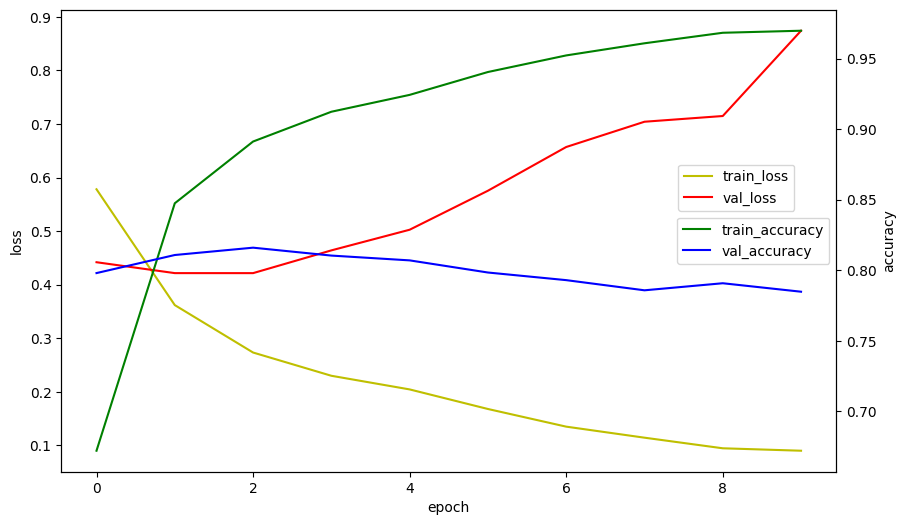

In [85]:
import matplotlib.pyplot as plt
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax = loss_ax.twinx() # loss_ax와 x축을 공유하는 acc_ax 생성
acc_ax.plot(hist.history['acc'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_acc'],'b',label='val_accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(bbox_to_anchor=(0.955,0.68))
acc_ax.legend(loc= 'center right')
plt.show()

In [84]:
# 테스트 데이터로 평가
loss, acc = model.evaluate(X_test,y_test)
print('test 데이터의 정확도 :', acc)

782/782 [==============================] - 7s 8ms/step - loss: 1.0005 - acc: 0.7574
test 데이터의 정확도 : 0.7573599815368652
